# Домашнее задание к семинару 12 (HW12)
Тема: временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

In [ ]:
# Базовые библиотеки для генерации данных, анализа и обучения простых моделей.
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import os

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [ ]:
SEED = 42

# Фиксируем seed, чтобы синтетический ряд и результаты были воспроизводимыми.
def set_seed(seed) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
os.makedirs('artifacts/figures', exist_ok=True)

In [ ]:
df = pd.read_csv('S12-hw-dataset.csv')
print("Размер датасета: ", df.shape)
df.head()

Размер датасета:  (4320, 2)


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4320 non-null   object 
 1   target  4320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 67.6+ KB


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df['date'].dtype)
print(df.head())

datetime64[ns]
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62


In [ ]:
print(f"Число наюлюдений: {len(df)}")
print(f"Диапазон дат: {df.date.min()} - {df.date.max()}")

Число наюлюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00


In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропуски': missing_values,
    'Процент': missing_percentage
})
print("Число пропусков по колонкам:")
print(missing_df)

Число пропусков по колонкам:
        Пропуски  Процент
date           0      0.0
target         0      0.0


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


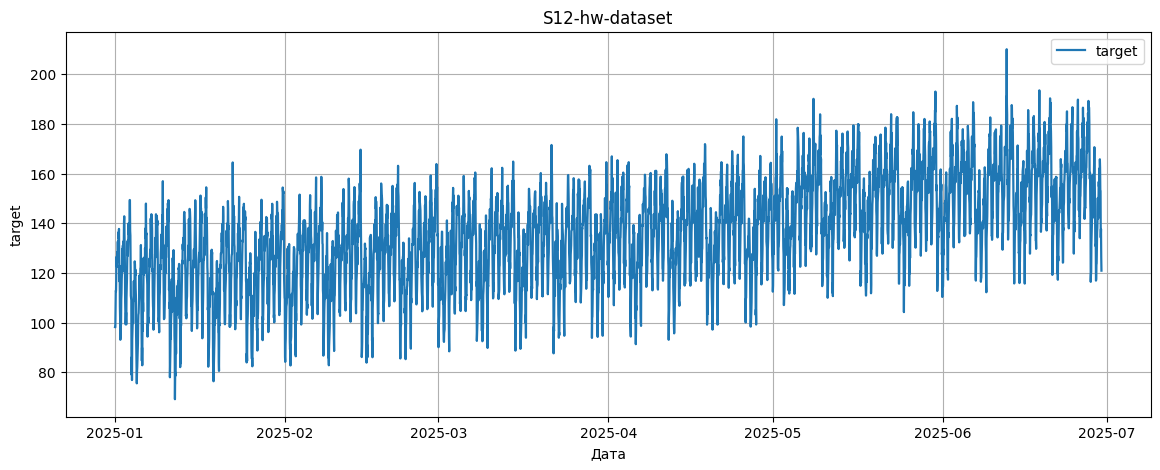

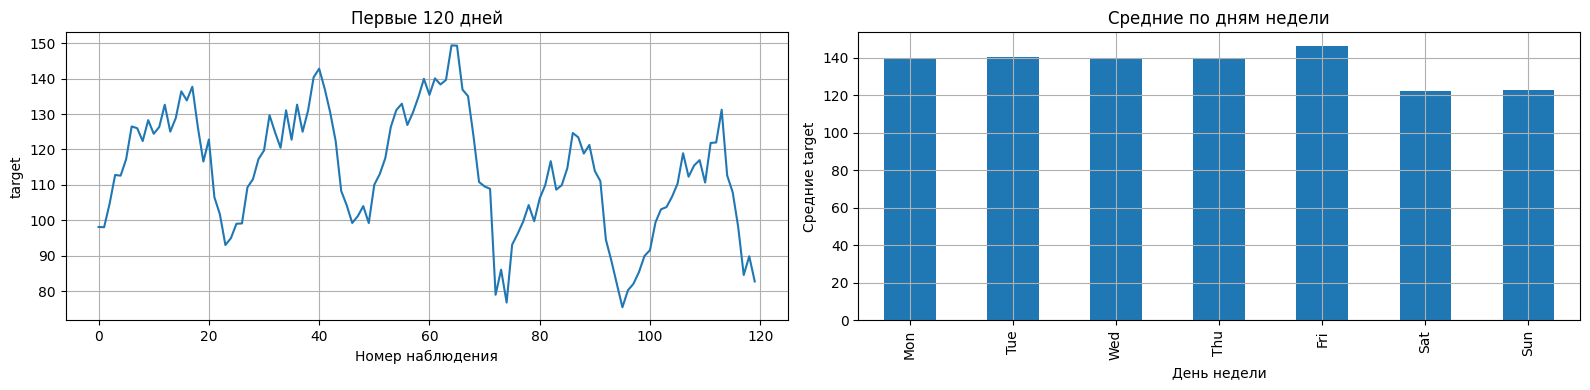

In [ ]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("S12-hw-dataset")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средние target")

plt.tight_layout()
plt.show()


train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


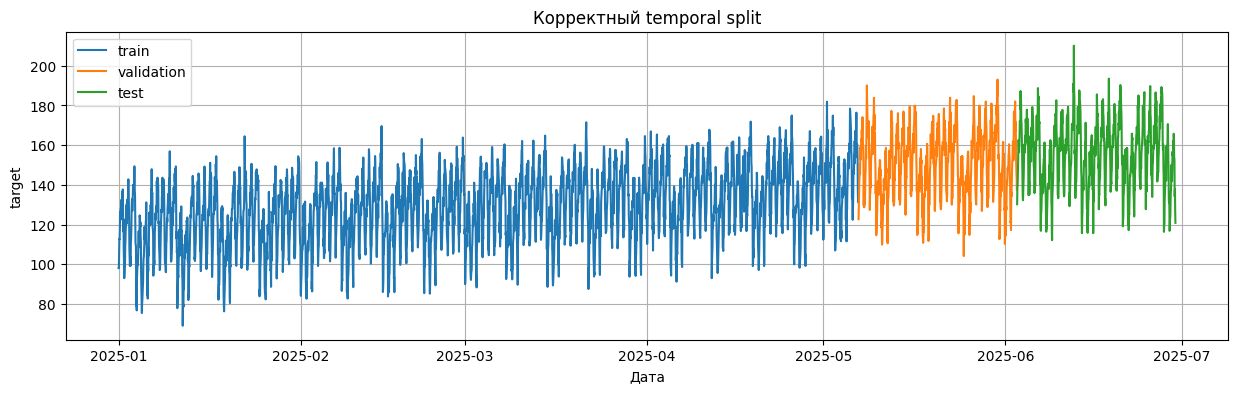

In [ ]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()

plt.savefig("./artifacts/figures/series_split.png", dpi=150, bbox_inches='tight')

plt.show()

`random split` здесь некорректен: при случайном перемешивании нарушается временная структура ряда, что приводит к утечке будущей информации в обучающую выборку и создаёт иллюзию высокой точности модели, которая не сможет работать на реальных временных рядах.

Утечки данных могли бы возникнуть при использовании random split (информация из будущего попадала бы в обучение) или при построении признаков с заглядыванием вперёд (например, если бы rolling-статистики рассчитывались с учетом будущих данных). В работе все преобразования выполнялись с соблюдением временного порядка.

In [ ]:
def add_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()

    return out

features_df = add_features(df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,0.974928,-0.222521,0.5,0.866025,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,0.974928,-0.222521,0.5,0.866025,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,0.974928,-0.222521,0.5,0.866025,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,0.974928,-0.222521,0.5,0.866025,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,0.974928,-0.222521,0.5,0.866025,137.71,126.35,112.62,131.550000,4.907936


In [ ]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 11) | y_train: (3014,)
X_val:   (646, 11) | y_val:   (646,)
X_test:  (646, 11) | y_test:  (646,)


- **B1 (`naive-last`)**: наивный baseline, где прогноз равен последнему известному значению.

In [ ]:
results = []


def create_experiment_row(exp_id, model_summary, features_summary, best_val_mae, best_val_rmse, best_val_mape,
                          split_summary='temporal_split_70/15/15',
                          window_size=None, scaler=None,
                          optimizer=None, lr=None, epochs_trained=None,
                          test_mae=None, test_rmse=None, test_mape=None, notes=None):

    return {
        "experiment_id": exp_id,
        "task": 'forecasting',
        "dataset": 'S12-hw-dataset.csv',
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": 1,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": float(round(best_val_mae, 6)),
        "best_val_rmse": float(round(best_val_rmse, 6)),
        "best_val_mape": float(round(best_val_mae, 6)),
        "test_mae": float(round(test_mae, 6)) if test_mae else None,
        "test_rmse": float(round(test_rmse, 6)) if test_rmse else None,
        "test_mape": float(round(test_mape, 6)) if test_mape else None,
        "notes": None,
    }

In [ ]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

In [ ]:
# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()

print("Validation:")
b1_val_res = evaluate_regression(y_val, val_pred_naive, "naive-last (lag_1)")
display(b1_val_res)

Validation:


,model,MAE,RMSE,MAPE_%
0,naive-last (lag_1),6.443406,8.203532,4.394594


In [ ]:
results.append(create_experiment_row('B1', b1_val_res['model'].iloc[0],
                                     feature_cols, b1_val_res['MAE'].iloc[0], b1_val_res['RMSE'].iloc[0],
                                     b1_val_res['MAPE_%'].iloc[0]))
results

[{'experiment_id': 'B1',
  'task': 'forecasting',
  'dataset': 'S12-hw-dataset.csv',
  'seed': 42,
  'split_summary': 'temporal_split_70/15/15',
  'window_size': None,
  'horizon': 1,
  'model_summary': 'naive-last (lag_1)',
  'features_summary': ['dayofweek',
   'month',
   'dow_sin',
   'dow_cos',
   'month_sin',
   'month_cos',
   'lag_1',
   'lag_7',
   'lag_14',
   'rolling_mean_7',
   'rolling_std_7'],
  'scaler': None,
  'optimizer': None,
  'lr': None,
  'epochs_trained': None,
  'best_val_mae': 6.443406,
  'best_val_rmse': 8.203532,
  'best_val_mape': 6.443406,
  'test_mae': None,
  'test_rmse': None,
  'test_mape': None,
  'notes': None}]

In [ ]:
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()

print("Validation:")
b2_val_res = evaluate_regression(y_val, val_pred_ma7, "moving-average (7)")
display(b2_val_res)

Validation:


,model,MAE,RMSE,MAPE_%
0,moving-average (7),12.723717,15.236326,8.828779


In [ ]:
results.append(create_experiment_row('B2', b2_val_res['model'].iloc[0],
                                     feature_cols, b2_val_res['MAE'].iloc[0], b2_val_res['RMSE'].iloc[0],
                                     b2_val_res['MAPE_%'].iloc[0]))
results[-1]

{'experiment_id': 'B2',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset.csv',
 'seed': 42,
 'split_summary': 'temporal_split_70/15/15',
 'window_size': None,
 'horizon': 1,
 'model_summary': 'moving-average (7)',
 'features_summary': ['dayofweek',
  'month',
  'dow_sin',
  'dow_cos',
  'month_sin',
  'month_cos',
  'lag_1',
  'lag_7',
  'lag_14',
  'rolling_mean_7',
  'rolling_std_7'],
 'scaler': None,
 'optimizer': None,
 'lr': None,
 'epochs_trained': None,
 'best_val_mae': 12.723717,
 'best_val_rmse': 15.236326,
 'best_val_mape': 12.723717,
 'test_mae': None,
 'test_rmse': None,
 'test_mape': None,
 'notes': None}

- **B3 (`ridge-lag-features`)**: `Ridge` на лаговых, rolling- и календарных признаках.

In [ ]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
b3_val_res = evaluate_regression(y_val, val_pred_ridge, "ridge-lag-features")
display(b3_val_res)

,model,MAE,RMSE,MAPE_%
0,ridge-lag-features,6.441301,7.944266,4.304582


In [ ]:
results.append(create_experiment_row('B3', b3_val_res['model'].iloc[0],
                                     feature_cols, b3_val_res['MAE'].iloc[0], b3_val_res['RMSE'].iloc[0],
                                     b3_val_res['MAPE_%'].iloc[0], scaler=scaler.__class__.__name__))
results[-1]

{'experiment_id': 'B3',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset.csv',
 'seed': 42,
 'split_summary': 'temporal_split_70/15/15',
 'window_size': None,
 'horizon': 1,
 'model_summary': 'ridge-lag-features',
 'features_summary': ['dayofweek',
  'month',
  'dow_sin',
  'dow_cos',
  'month_sin',
  'month_cos',
  'lag_1',
  'lag_7',
  'lag_14',
  'rolling_mean_7',
  'rolling_std_7'],
 'scaler': 'StandardScaler',
 'optimizer': None,
 'lr': None,
 'epochs_trained': None,
 'best_val_mae': 6.441301,
 'best_val_rmse': 7.944266,
 'best_val_mape': 6.441301,
 'test_mae': None,
 'test_rmse': None,
 'test_mape': None,
 'notes': None}

- **R1 (`gru-forecast`)**: `GRU` на оконном представлении ряда.

In [ ]:
train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


In [ ]:
# 1. Нормализация данных ТОЛЬКО по train набору
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


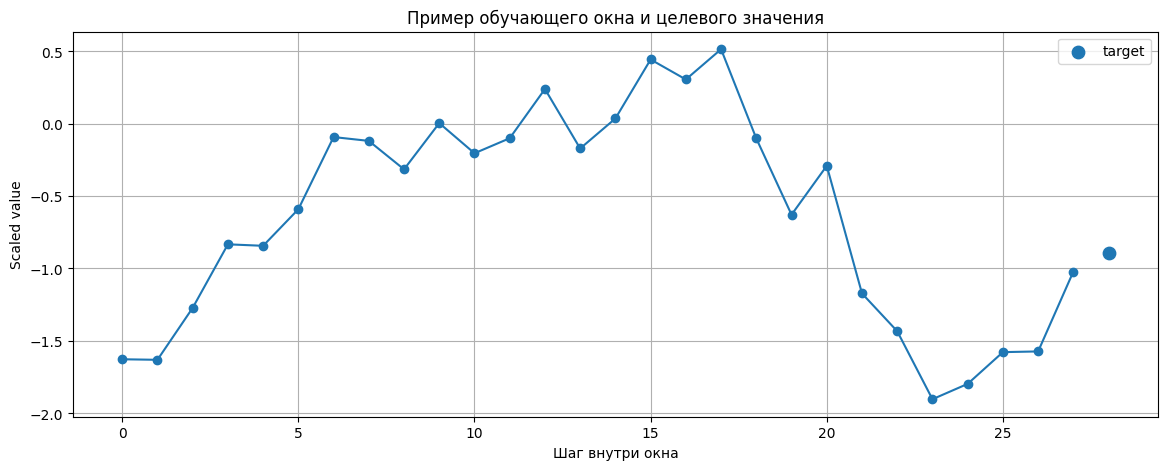

In [ ]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [ ]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [ ]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [ ]:
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.6699 | val_loss=0.5719
Epoch 02 | train_loss=0.2764 | val_loss=0.2806
Epoch 03 | train_loss=0.1617 | val_loss=0.1782
Epoch 04 | train_loss=0.1530 | val_loss=0.2009
Epoch 05 | train_loss=0.1508 | val_loss=0.1825
Epoch 06 | train_loss=0.1504 | val_loss=0.1834
Epoch 07 | train_loss=0.1495 | val_loss=0.1887
Epoch 08 | train_loss=0.1467 | val_loss=0.1972
Epoch 09 | train_loss=0.1458 | val_loss=0.1832
Epoch 10 | train_loss=0.1454 | val_loss=0.1821
Epoch 11 | train_loss=0.1432 | val_loss=0.1713
Epoch 12 | train_loss=0.1446 | val_loss=0.1935
Epoch 13 | train_loss=0.1398 | val_loss=0.1923
Epoch 14 | train_loss=0.1406 | val_loss=0.2045
Epoch 15 | train_loss=0.1332 | val_loss=0.2112
Epoch 16 | train_loss=0.1284 | val_loss=0.2429
Epoch 17 | train_loss=0.1205 | val_loss=0.2524
Epoch 18 | train_loss=0.1151 | val_loss=0.2557
Epoch 19 | train_loss=0.1130 | val_loss=0.1976
Epoch 20 | train_loss=0.1072 | val_loss=0.1939
Epoch 21 | train_loss=0.1084 | val_loss=0

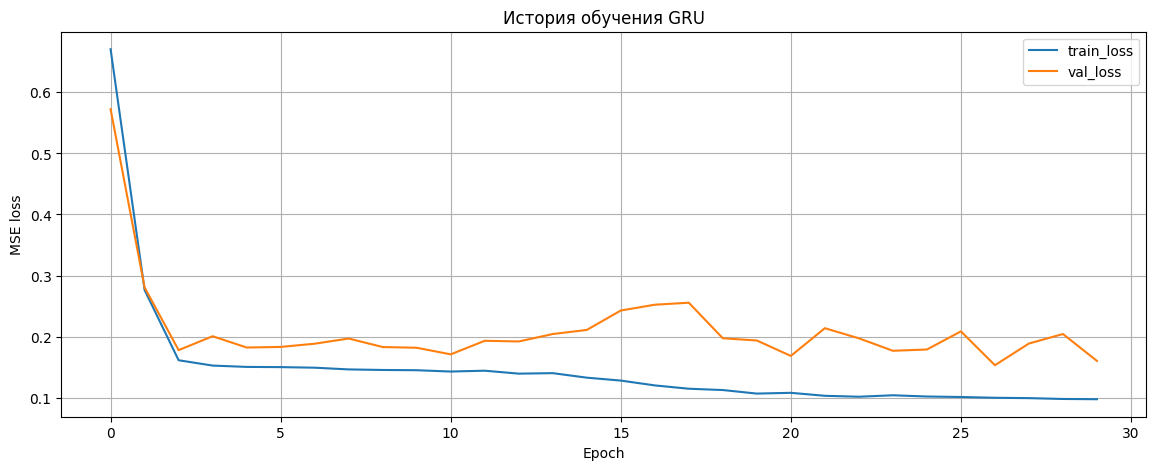

In [ ]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("./artifacts/figures/gru_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

In [ ]:
r1_val_res = evaluate_regression(val_true, gru_val_pred, "gru-forecast")

In [ ]:
r1_val_res

,model,MAE,RMSE,MAPE_%
0,gru-forecast,5.773033,7.440503,3.893466


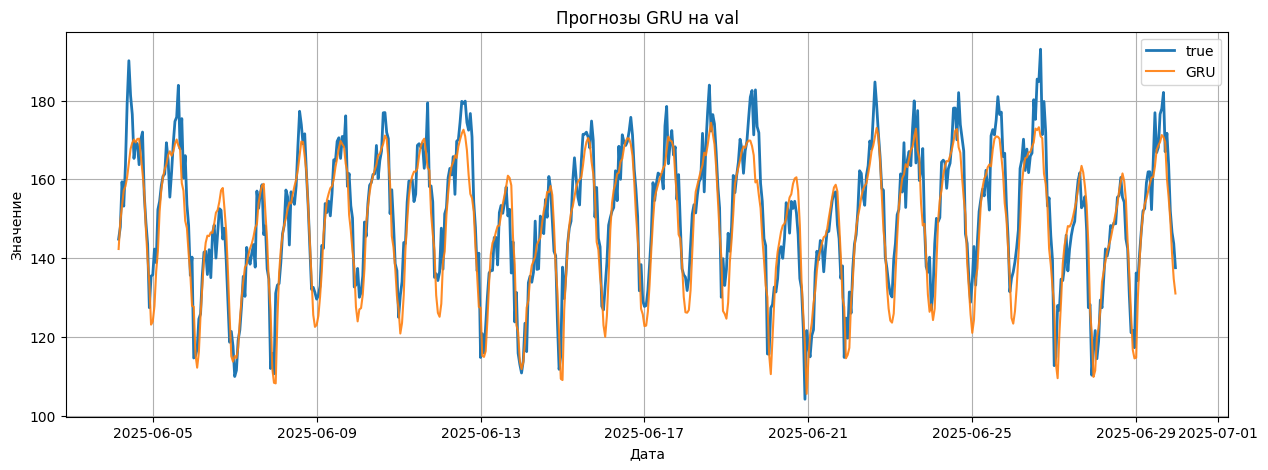

In [ ]:
# # Определяем лучшую модель и визуализируем результаты
# best_model_name = test_metrics.iloc[0]["model"]
# print("Лучшая модель на test:", best_model_name)

# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": val_true,
        "gru": gru_val_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Прогнозы GRU на val")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

In [ ]:
val_pred_results = pd.concat([
    b1_val_res,
    b2_val_res,
    b3_val_res,
    r1_val_res
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
val_pred_results

,model,MAE,RMSE,MAPE_%
0,gru-forecast,5.773033,7.440503,3.893466
1,ridge-lag-features,6.441301,7.944266,4.304582
2,naive-last (lag_1),6.443406,8.203532,4.394594
3,moving-average (7),12.723717,15.236326,8.828779


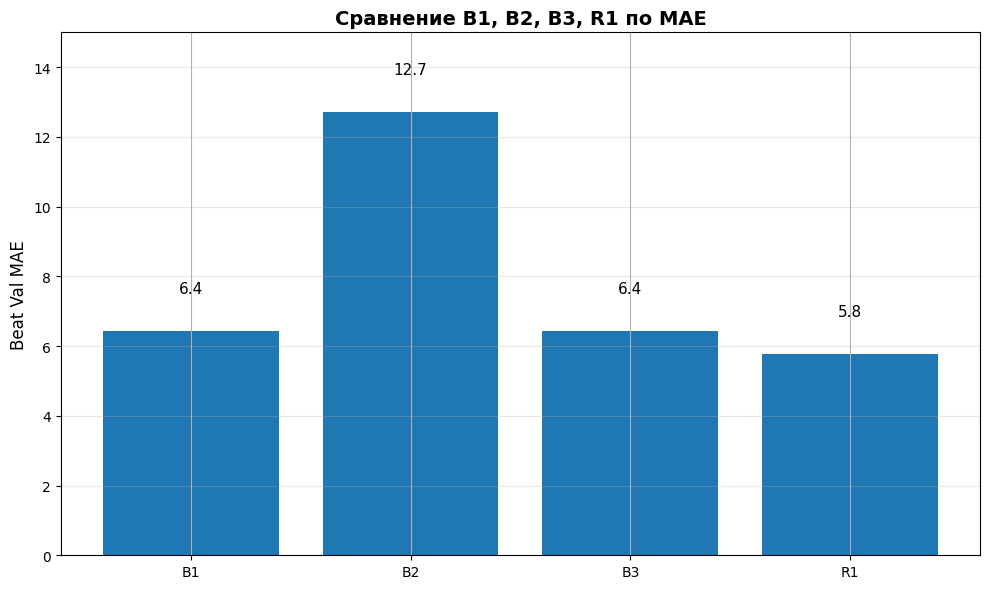

In [ ]:
methods = ['B1', 'B2', 'B3', 'R1']
best_val_mae = [b1_val_res['MAE'].iloc[0], b2_val_res['MAE'].iloc[0], b3_val_res['MAE'].iloc[0], r1_val_res['MAE'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, best_val_mae)
ax.set_ylabel('Beat Val MAE', fontsize=12)
ax.set_title('Сравнение B1, B2, B3, R1 по MAE',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 15)

# Добавление значений на столбцы
for bar, acc in zip(bars, best_val_mae):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1f}', ha='center', va='bottom', fontsize=11)

# Добавление сетки
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("./artifacts/figures/baselines_compare.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_model = val_pred_results['model'].iloc[0]
print(f"Лучшая модель на валидации: {best_model}")


Лучшая модель на валидации: gru-forecast


In [ ]:
# Оценка лучшей моедли на TEST
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

# Восстанавливаем исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics  = evaluate_regression(test_true, gru_test_pred, "gru-forecast-test")


test_metrics

,model,MAE,RMSE,MAPE_%
0,gru-forecast-test,7.017684,8.864461,4.50993


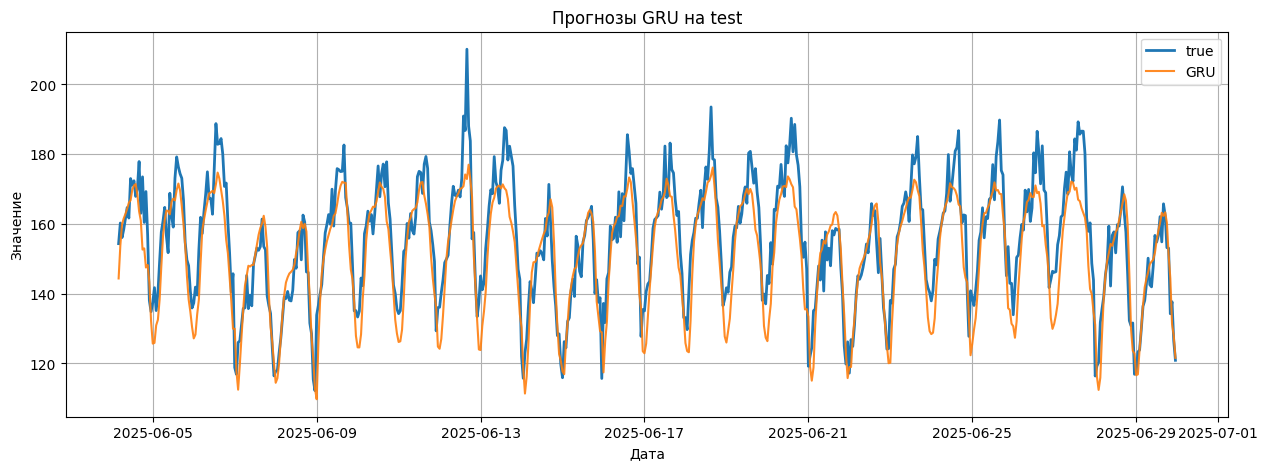

In [ ]:
# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Прогнозы GRU на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("./artifacts/figures/best_forecast_test.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
results.append(create_experiment_row('R1', r1_val_res['model'].iloc[0], "day[i-window_size]..day[i-1]",
                                     r1_val_res['MAE'].iloc[0], r1_val_res['RMSE'].iloc[0],
                                     r1_val_res['MAPE_%'].iloc[0], scaler=scaler.__class__.__name__, lr=1e-3,
               optimizer= 'Adam', epochs_trained=12, test_mae=test_metrics['MAE'].iloc[0], test_rmse=test_metrics['RMSE'].iloc[0],
               test_mape=test_metrics['MAPE_%'].iloc[0], window_size = 28)
               )
results[-1]

{'experiment_id': 'R1',
 'task': 'forecasting',
 'dataset': 'S12-hw-dataset.csv',
 'seed': 42,
 'split_summary': 'temporal_split_70/15/15',
 'window_size': 28,
 'horizon': 1,
 'model_summary': 'gru-forecast',
 'features_summary': 'day[i-window_size]..day[i-1]',
 'scaler': 'StandardScaler',
 'optimizer': 'Adam',
 'lr': 0.001,
 'epochs_trained': 12,
 'best_val_mae': 5.773033,
 'best_val_rmse': 7.440503,
 'best_val_mape': 5.773033,
 'test_mae': 7.017684,
 'test_rmse': 8.864461,
 'test_mape': 4.50993,
 'notes': None}

In [ ]:
df_results = pd.DataFrame(results)
print(df_results.to_string())

df_results.to_csv("./artifacts/runs.csv", index=False)
print(f"\nРезультаты сохранены в './artifacts/runs.csv'")

  experiment_id         task             dataset  seed            split_summary  window_size  horizon       model_summary                                                                                                 features_summary          scaler optimizer     lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape notes
0            B1  forecasting  S12-hw-dataset.csv    42  temporal_split_70/15/15          NaN        1  naive-last (lag_1)  [dayofweek, month, dow_sin, dow_cos, month_sin, month_cos, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7]            None      None    NaN             NaN      6.443406       8.203532       6.443406       NaN        NaN        NaN  None
1            B2  forecasting  S12-hw-dataset.csv    42  temporal_split_70/15/15          NaN        1  moving-average (7)  [dayofweek, month, dow_sin, dow_cos, month_sin, month_cos, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7]            None      None    NaN 

In [ ]:
torch.save(gru_model.state_dict(), "./artifacts/best_gru.pt")

In [ ]:
import json

best_config = {
    "experiment_id": "R1",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "model": 'GRU',
    "optimizer": "Adam",
    "lr": 1e-3,
    "window_size": 28,
    "batch_size": batch_size,
    "epochs_trained": 12,
    "hidden size": 48,
    "scaler": 'StandardScaler',
    "best_val_mae": r1_val_res['MAE'].iloc[0],
    "best_val_rmse": r1_val_res['RMSE'].iloc[0],
    "best_val_mape": r1_val_res['MAPE_%'].iloc[0],
    "test_mae": test_metrics['MAE'].iloc[0],
    "test_rmse": test_metrics['RMSE'].iloc[0],
    "test_mape": test_metrics['MAPE_%'].iloc[0],
}

# Сохраняем в JSON
with open("./artifacts/best_gru_config.json", "w") as f:
    json.dump(best_config, f, indent=4)